In [35]:
options(repr.plot.width = 14, repr.plot.height = 7, repr.plot.res = 200)


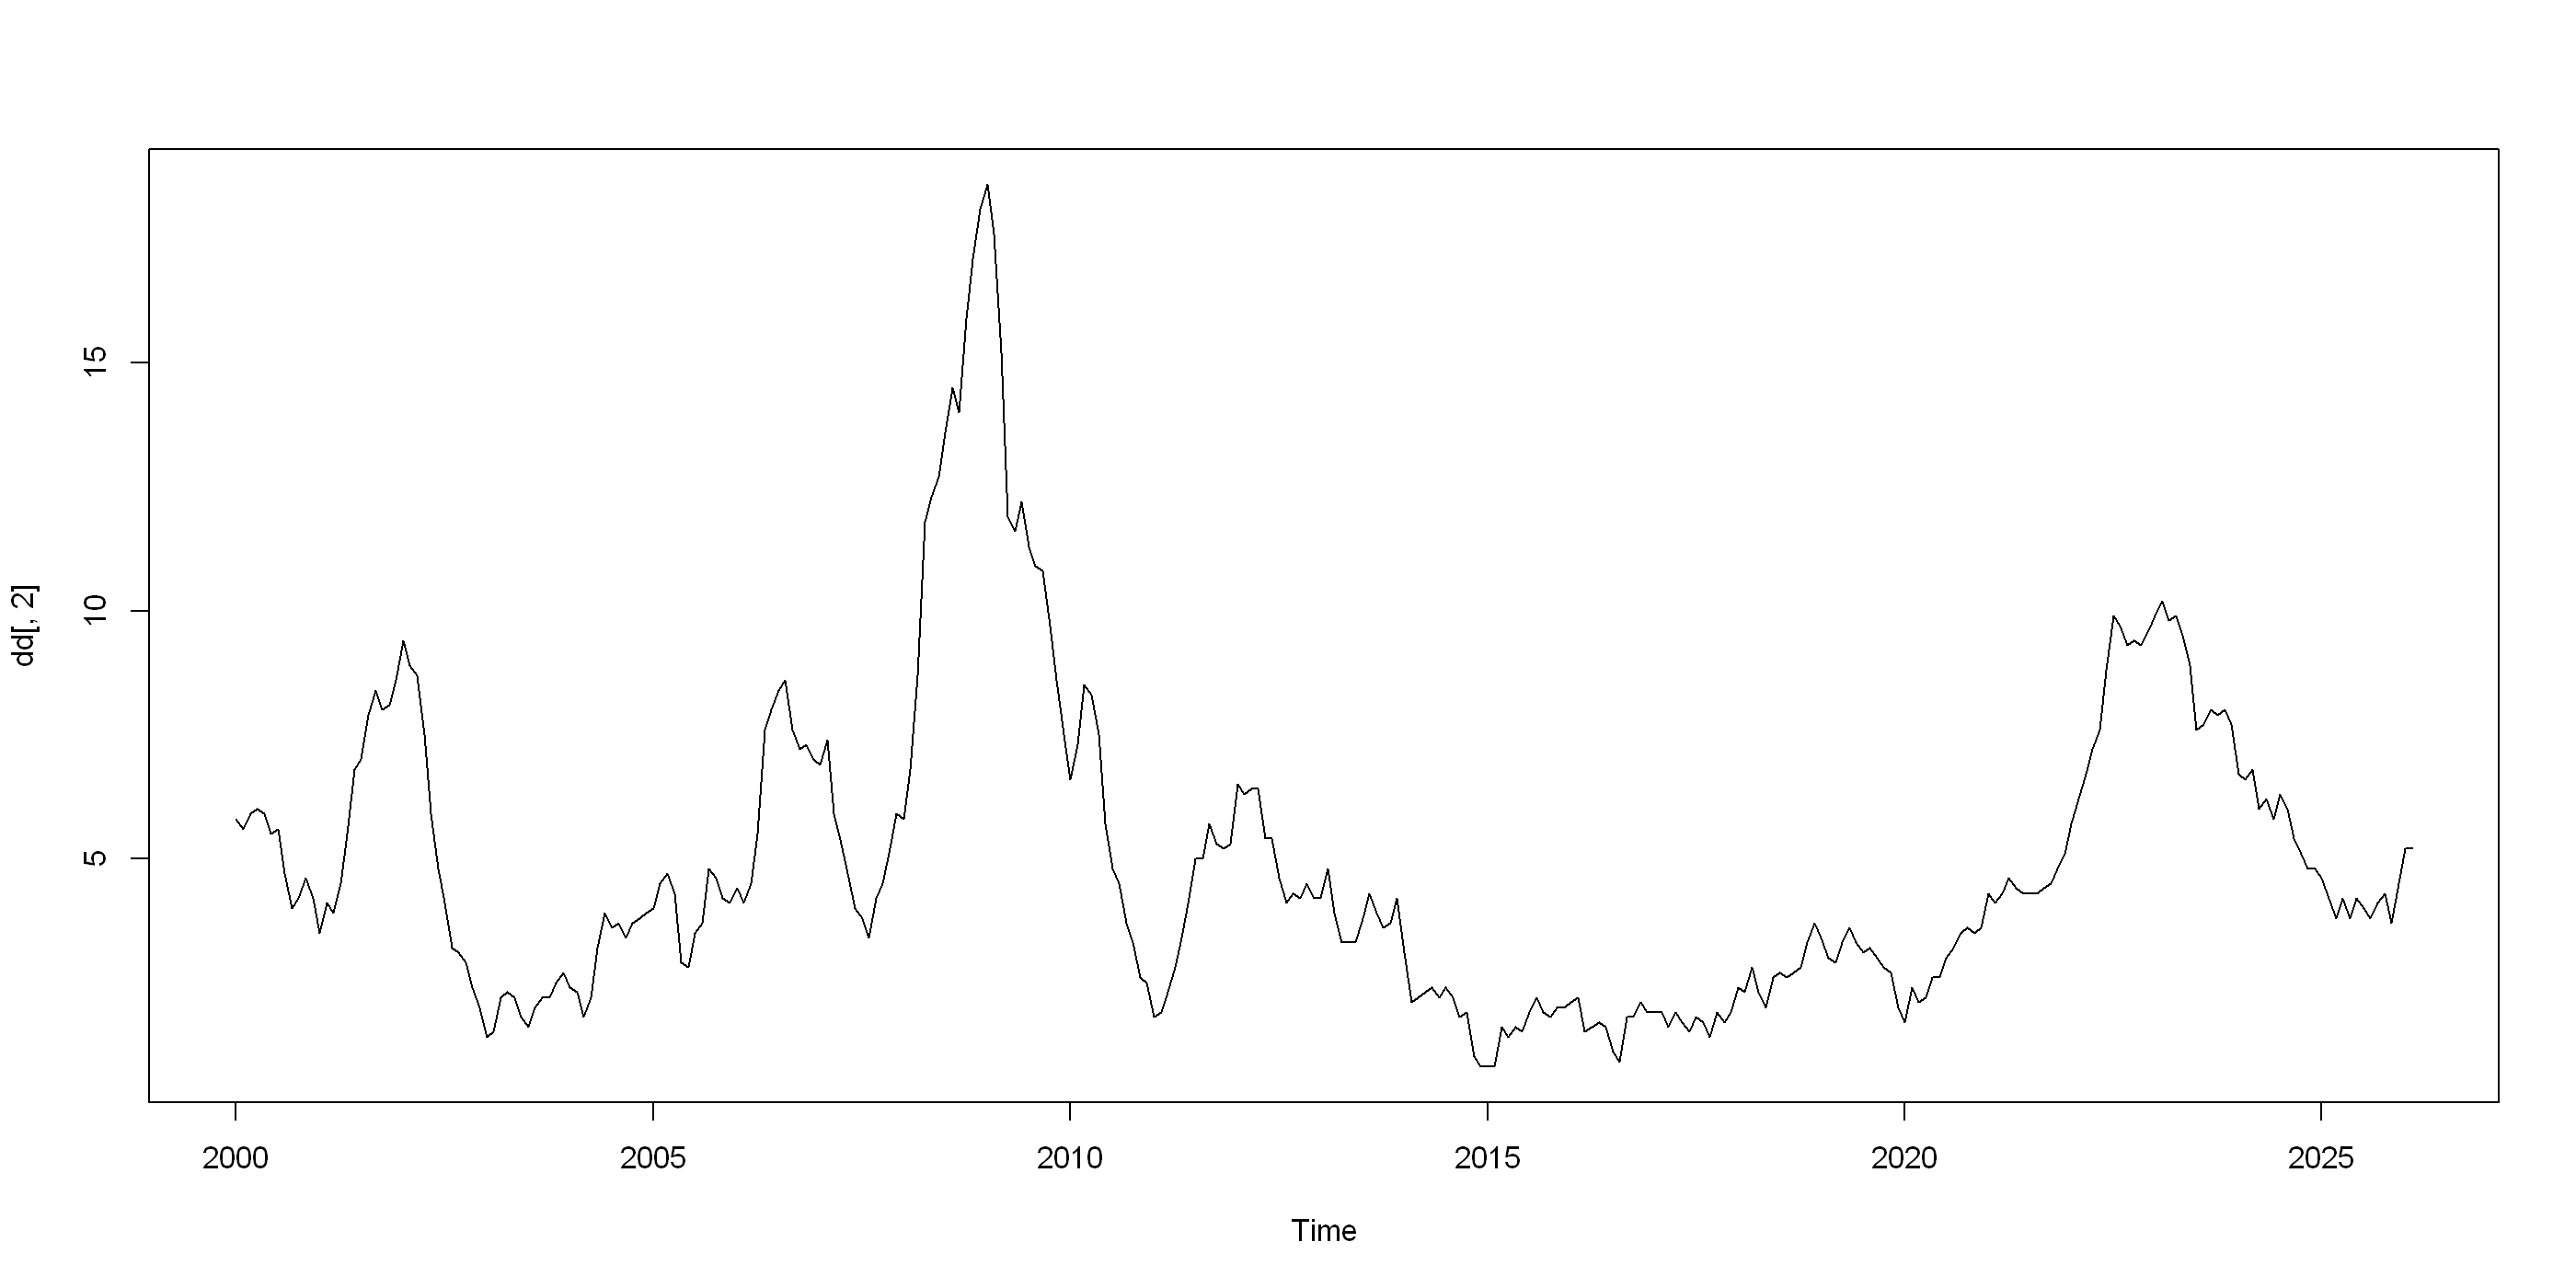

In [36]:
dd <- ts(read.csv("VIS01000 (2).csv",sep = ";"),start = c(2000,1),frequency = 12)
plot(dd[,2])

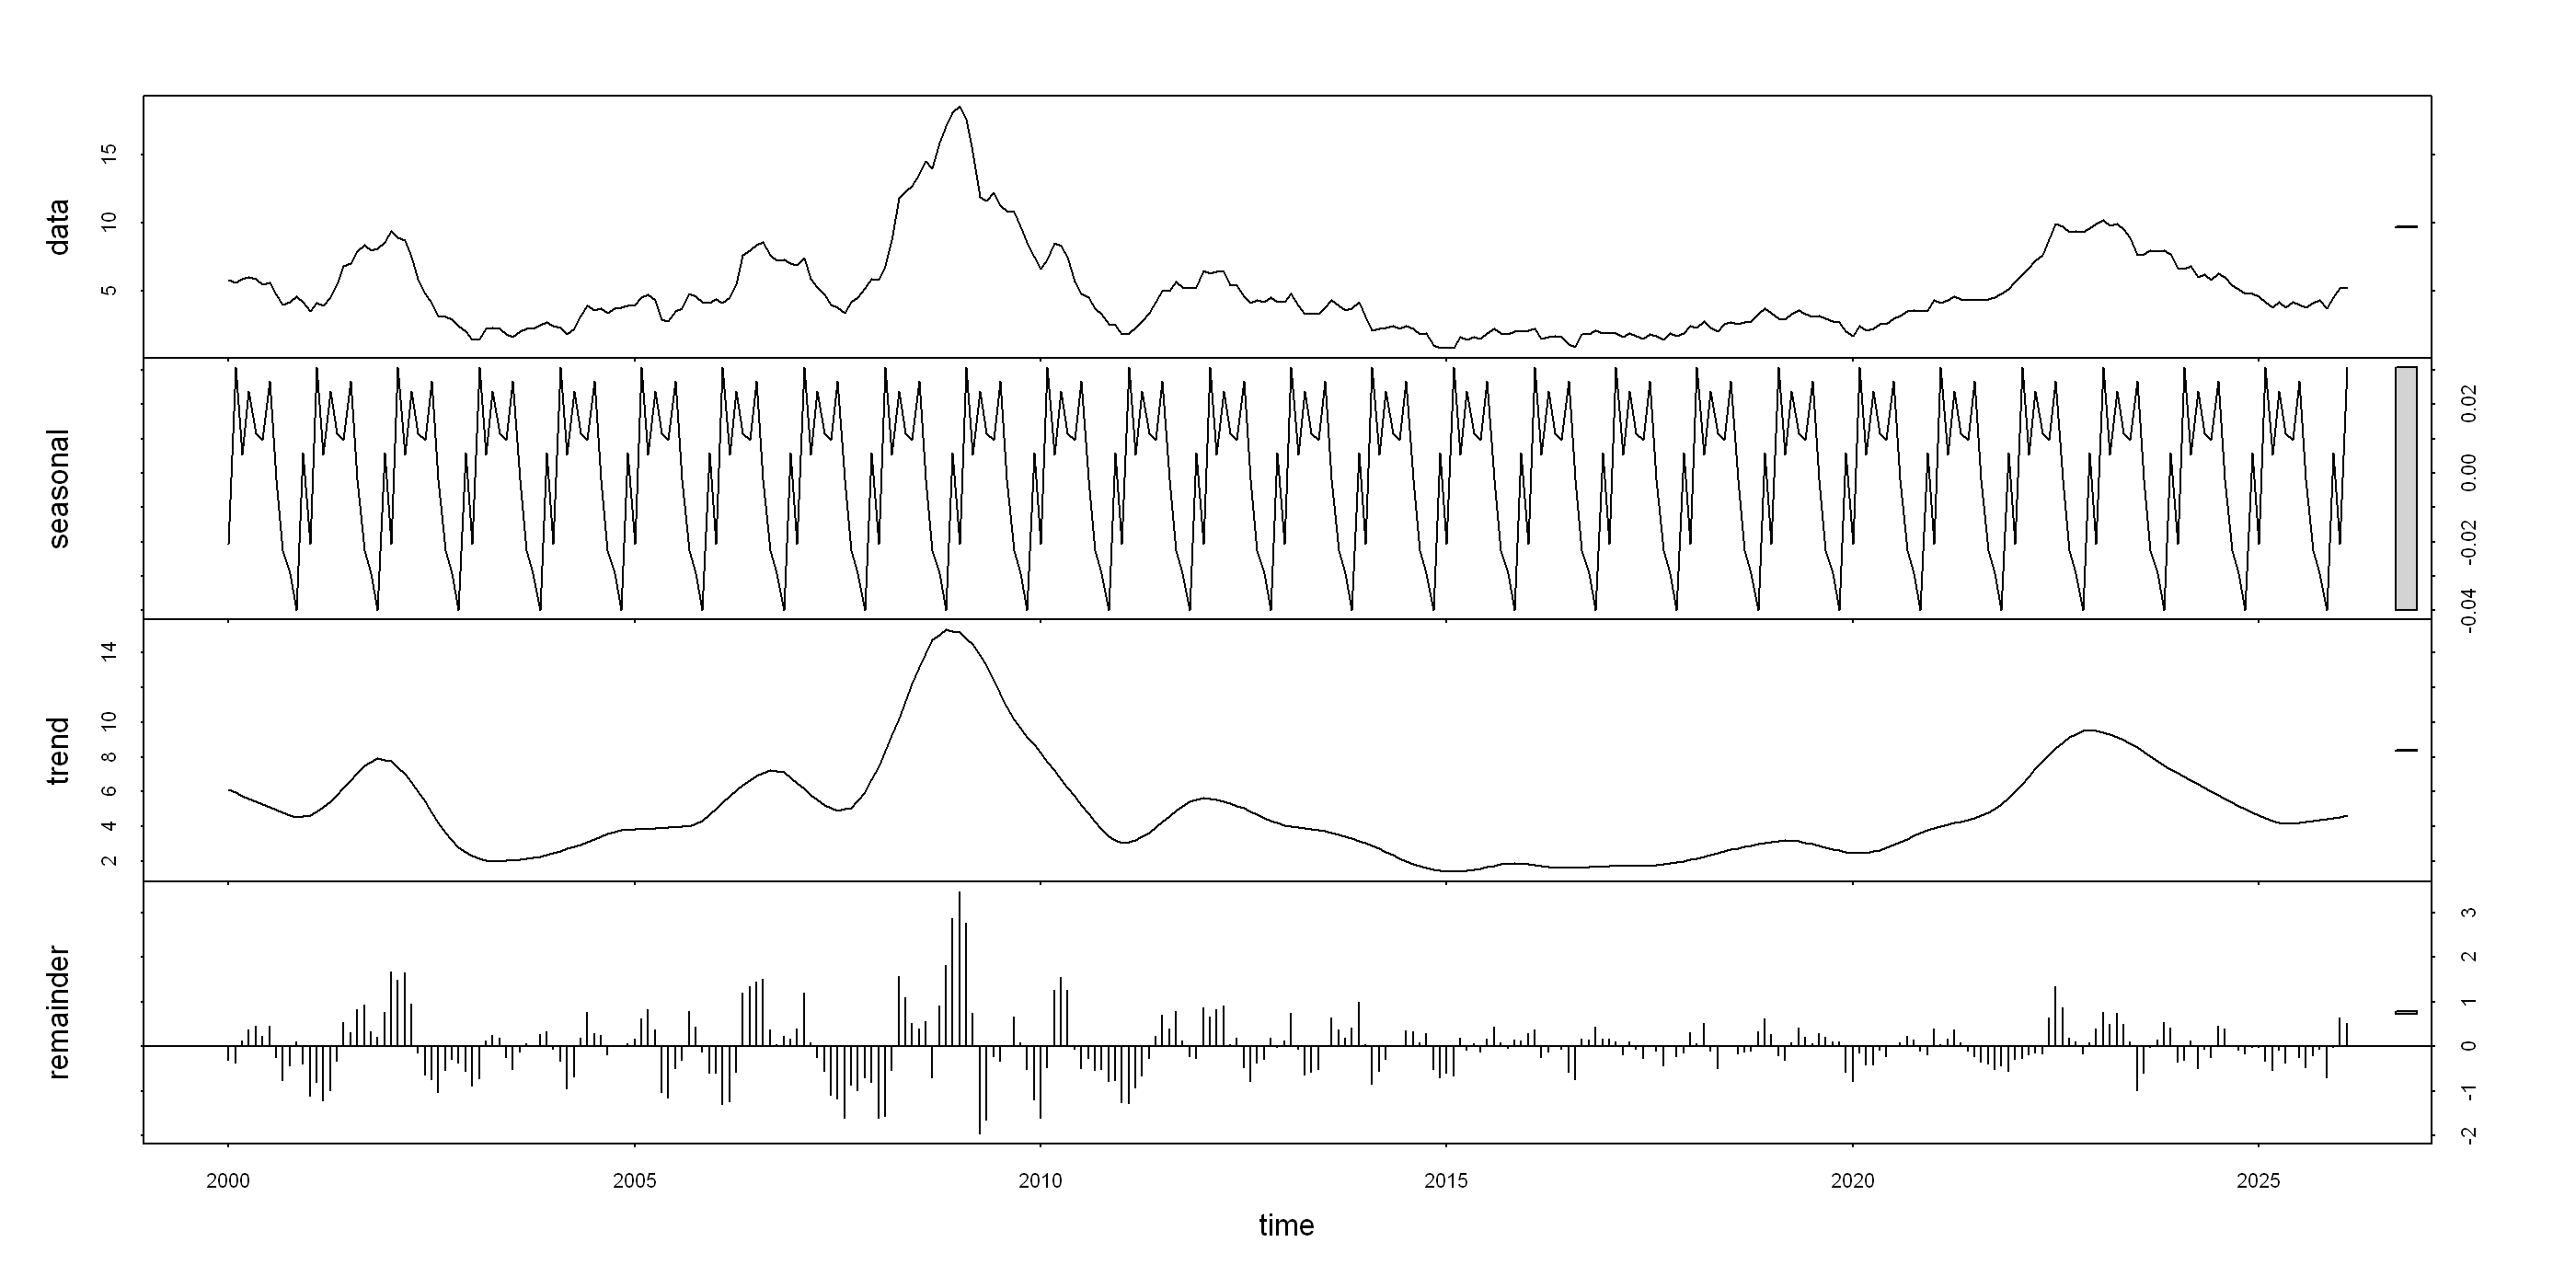

In [132]:
plot(stl(dd[,2],s.window = "periodic"))
cpi = dd[,2]
plot(stl(cpi,s.window = "periodic"))


[1] 5.308167 5.448791 5.632159


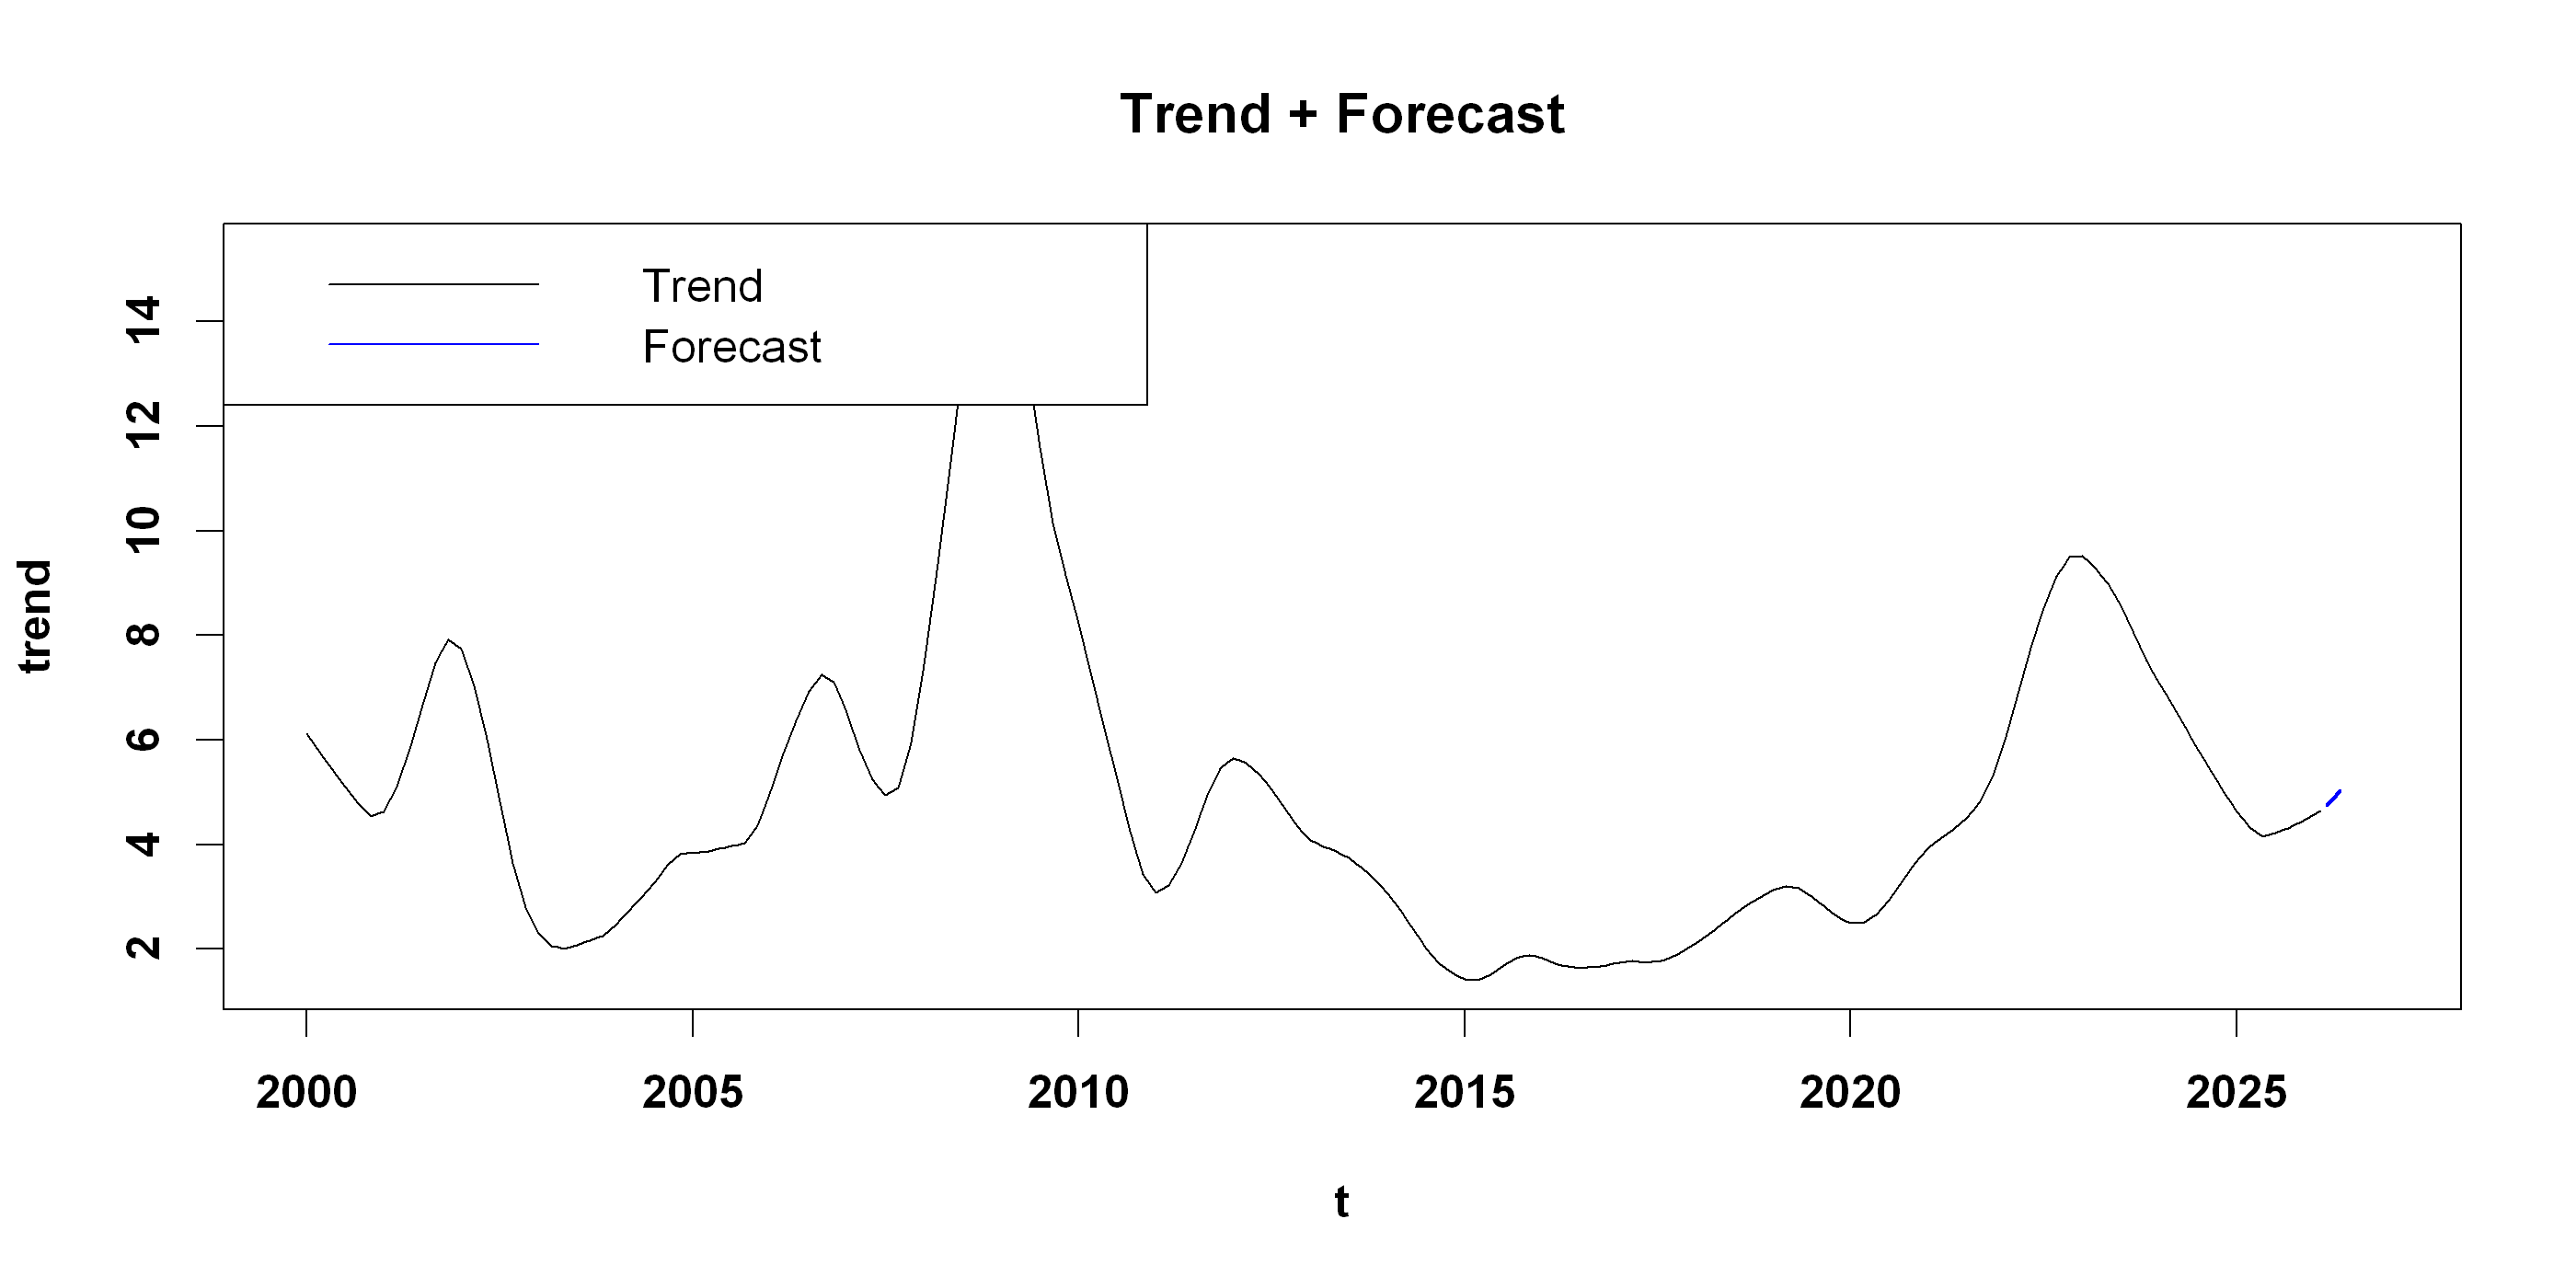

In [145]:
dd_stl <- stl(dd[, 2], s.window = "periodic")
trend <- dd_stl$time.series[, "trend"]

n <- length(trend)
t <- time(trend)
t_future <- t[n] + (1:3) / frequency(trend)

# spline interpolation of the trend, extrapolated 3 months
spl <- splinefun(as.numeric(t), as.numeric(trend))
forecast <- spl(t_future)

par(cex = 1.5, font.main = 2, font.axis = 2, font.lab = 2)
plot(t, trend, type = "l", main = "Trend + Forecast",
     xlim = c(min(t), max(t_future) + 0.5))
lines(t_future, forecast, col = "blue", type = "l", lwd = 2, pch = 16, cex = 1.5)
legend("topleft", legend = c("Trend", "Forecast"), col = c("black", "blue"), lty = 1)

print(forecast/trend[n] * 5.2)